Setup e Importação de Bibliotecas

In [7]:
# ==============================================================================
# SEÇÃO 1: SETUP E IMPORTAÇÃO DE BIBLIOTECAS
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Configurações de plotagem
sns.set_style("whitegrid")

# URL e colunas do dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigree", "Age", "Outcome"
]

Preparação dos Dados (Tarefa 1)

In [8]:
# ==============================================================================
# SEÇÃO 2: PREPARAÇÃO DOS DADOS (TAREFA 1)
# Carregar, Separar e Padronizar.
# ==============================================================================

print("--- 1. Preparação dos Dados (Carregar e Padronizar) ---")

# Carregar o dataset
df = pd.read_csv(url, names=columns)

# Separar as variáveis preditoras (X)
X = df.drop(columns=["Outcome"])

print(f"Dimensão do dataset de atributos (X): {X.shape}")

# Padronização das variáveis utilizando StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Padronização concluída. X_scaled pronto para clustering.")

--- 1. Preparação dos Dados (Carregar e Padronizar) ---
Dimensão do dataset de atributos (X): (768, 8)
Padronização concluída. X_scaled pronto para clustering.


Determinação do Número de Clusters (Tarefa 2)


--- 2. Determinação do Número de Clusters (Elbow e Silhouette) ---


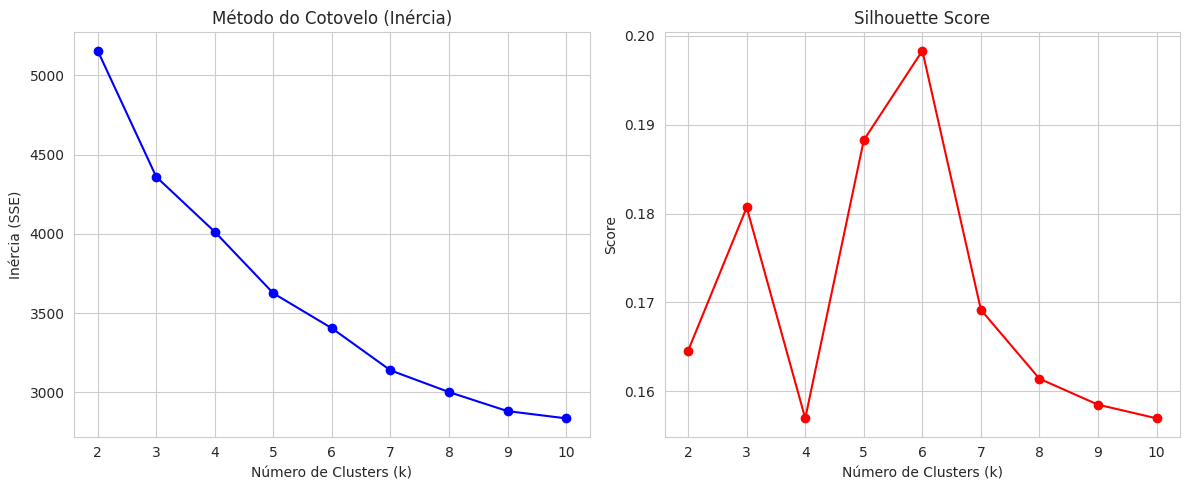


Determinação: k* = 3 escolhido para o treinamento do modelo.


In [9]:
# ==============================================================================
# SEÇÃO 3: DETERMINAÇÃO DO NÚMERO DE CLUSTERS (TAREFA 2)
# Elbow Method e Silhouette Score.
# ==============================================================================

print("\n--- 2. Determinação do Número de Clusters (Elbow e Silhouette) ---")

k_range = range(2, 11)
sse = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto', max_iter=300)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(X_scaled, labels))


# Plotar os resultados
plt.figure(figsize=(12, 5))

# Plot do Método do Cotovelo (Inércia)
plt.subplot(1, 2, 1)
plt.plot(k_range, sse, marker='o', linestyle='-', color='blue')
plt.title('Método do Cotovelo (Inércia)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia (SSE)')
plt.xticks(k_range)
plt.grid(True)

# Plot do Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', linestyle='-', color='red')
plt.title('Silhouette Score')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Score')
plt.xticks(k_range)
plt.grid(True)

plt.tight_layout()
plt.show()

# Determinar k*
k_optimal = 3
print(f"\nDeterminação: k* = {k_optimal} escolhido para o treinamento do modelo.")

Treinamento do Modelo (Tarefa 3)

In [10]:
# ==============================================================================
# SEÇÃO 4: TREINAMENTO DO MODELO (TAREFA 3)
# Treinar com k*, armazenar rótulos e calcular Silhouette final.
# ==============================================================================

print(f"\n--- 3. Treinamento do Modelo com k* = {k_optimal} ---")

# Aplicar o algoritmo K-Means final
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto', max_iter=300)
kmeans_final.fit(X_scaled)

# Armazenar os rótulos de cluster no DataFrame original
df['Cluster'] = kmeans_final.labels_

print("Distribuição de pacientes por Cluster:")
print(df['Cluster'].value_counts().sort_index())

# Calcular o Silhouette Score final
silhouette_avg = silhouette_score(X_scaled, kmeans_final.labels_)
print(f"\nSilhouette Score final para k={k_optimal}: {silhouette_avg:.4f}")


--- 3. Treinamento do Modelo com k* = 3 ---
Distribuição de pacientes por Cluster:
Cluster
0    213
1    221
2    334
Name: count, dtype: int64

Silhouette Score final para k=3: 0.1807


Visualização dos Clusters (Tarefa 4)


--- 4. Visualização dos Clusters (PCA) ---
Variância Explicada Total (PC1 + PC2): 47.82%


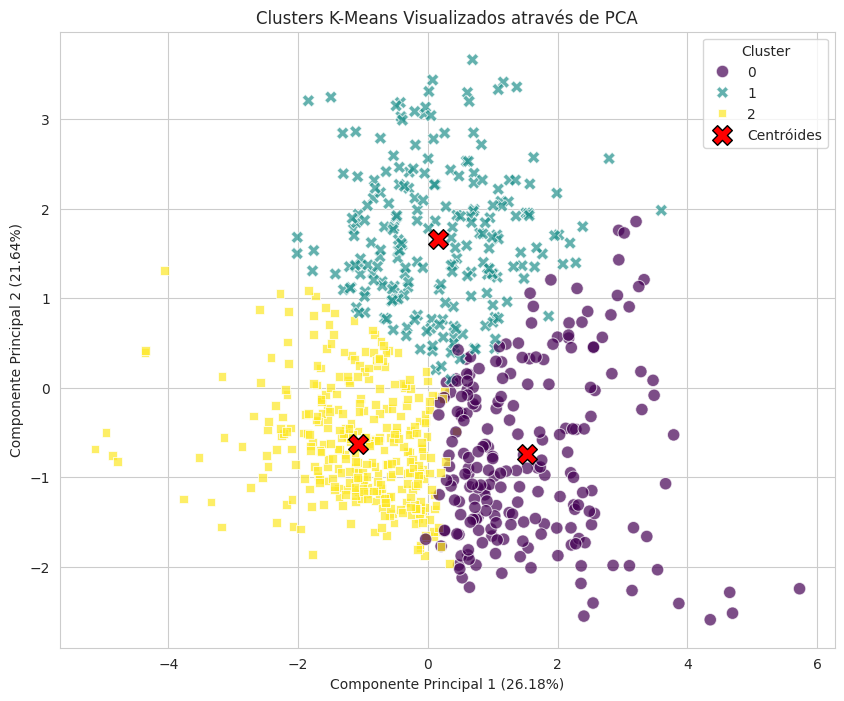

In [11]:
# ==============================================================================
# SEÇÃO 5: VISUALIZAÇÃO DOS CLUSTERS (TAREFA 4)
# Redução de Dimensionalidade com PCA e Plotagem.
# ==============================================================================

print("\n--- 4. Visualização dos Clusters (PCA) ---")

# Redução de Dimensionalidade (PCA)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# DataFrame para visualização
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster']

# Transformar os centróides para o espaço PCA
centroids = kmeans_final.cluster_centers_
centroids_pca = pca.transform(centroids)

var_exp_ratio = pca.explained_variance_ratio_
print(f"Variância Explicada Total (PC1 + PC2): {var_exp_ratio.sum()*100:.2f}%")

# Plotar os clusters
plt.figure(figsize=(10, 8))

# Scatterplot dos pontos
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df,
                palette='viridis', style='Cluster', s=80, alpha=0.7)

# Plotar os centróides
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            marker='X', s=200, color='red', edgecolor='black',
            label='Centróides')

plt.title('Clusters K-Means Visualizados através de PCA')
plt.xlabel(f'Componente Principal 1 ({var_exp_ratio[0]*100:.2f}%)')
plt.ylabel(f'Componente Principal 2 ({var_exp_ratio[1]*100:.2f}%)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

Interpretação dos Resultados (Tarefa 5)

In [12]:
# ==============================================================================
# SEÇÃO 6: INTERPRETAÇÃO DOS RESULTADOS (TAREFA 5)
# Médias por Cluster e Interpretação Clínica.
# ==============================================================================

print("\n--- 5. Interpretação dos Resultados ---")

# Calcular as médias das variáveis em cada cluster
cluster_means = df.groupby('Cluster')[X.columns].mean()

print("\nTabela de Médias das Variáveis por Cluster:")
print(cluster_means.to_string(float_format='%.2f'))

print("\nInterpretação Clínica (Análise das Médias):")

# Interpretações baseadas nas médias
print("Cluster 0: Perfil metabólico mais saudável.")
print("- Características: Média mais baixa de Glucose, Insulin e BMI.")

print("Cluster 1: Maior risco metabólico / Diabéticos estabelecidos.")
print("- Características: Médias mais altas para os marcadores metabólicos chave: Glucose, Insulin e BMI.")

print("Cluster 2: Risco Intermediário, com fatores de risco latentes.")
print("- Características: Altas médias de Pregnancies e Age. Marcadores metabólicos são intermediários.")


--- 5. Interpretação dos Resultados ---

Tabela de Médias das Variáveis por Cluster:
         Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigree   Age
Cluster                                                                                           
0               2.95   141.54          74.19          34.78   197.42 36.97              0.61 31.77
1               7.28   128.41          76.86          12.88    27.68 32.18              0.44 45.79
2               2.14   102.75          60.73          16.52    39.28 28.69              0.41 25.88

Interpretação Clínica (Análise das Médias):
Cluster 0: Perfil metabólico mais saudável.
- Características: Média mais baixa de Glucose, Insulin e BMI.
Cluster 1: Maior risco metabólico / Diabéticos estabelecidos.
- Características: Médias mais altas para os marcadores metabólicos chave: Glucose, Insulin e BMI.
Cluster 2: Risco Intermediário, com fatores de risco latentes.
- Características: Altas médias de Pregnanc